In [8]:
import torch
import random
from pathlib import Path
import matplotlib.pyplot as plt
from ultralytics import YOLO, settings
import time

In [9]:

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print("CUDA:", torch.version.cuda)

True
NVIDIA GeForce RTX 4060 Laptop GPU
CUDA: 12.1


In [10]:
current_dir=Path.cwd()
if current_dir.name=="notebook":
    project_root=current_dir.parent
else:
    project_root=current_dir
models_dir=project_root/"models"
output_dir=project_root/"outputs"/"yolo"
output_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)
settings.update({
    "weights_dir": str(models_dir)
})

In [ ]:


# train
pretrained_path=project_root/"models"/"yolo26s.pt"
model=YOLO(str(pretrained_path))
start=time.perf_counter()
model.train(
    data=str(project_root/"data_7class.yaml"),
    epochs=100,
    imgsz=640,
    batch=8,
    device=0,
    patience=10,
    amp=True,
    project=str(output_dir),
    name="Rail_Defect_Detect_7class",
    cache=False,
    workers=8, 
    seed=42,
    deterministic=True
)

elapsed=time.perf_counter()-start
print(f"Training time: {elapsed/60:.2f} minutes.")

Ultralytics 8.4.161  Python-3.12.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\Kun Bi\Desktop\rail_yolo_object_identification\data_7class.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=c:\Users\Kun Bi\Desktop\rail_yolo_object_ide

2026/09/29 13:31:43 INFO mlflow.tracking.fluent: Experiment with name 'c:\Users\Kun Bi\Desktop\rail_yolo_object_identification\outputs\yolo' does not exist. Creating a new experiment.


MLflow: logging run_id(8de3d8b52a30419294f74fd9f5e74905) to runs\mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs\mlflow'
MLflow: disable with 'yolo settings mlflow=False'
Using 6260 train, 592 val images for fraction=1.0 at imgsz=640
Using 8 dataloader workers
Logging results to C:\Users\Kun Bi\Desktop\rail_yolo_object_identification\outputs\yolo\Rail_Defect_Detect_7class-2
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100      2.15G      2.518      3.156      1.986         14        640: 100% ━━━━━━━━━━━━ 783/783 8.4it/s 1:330.1ssss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 37/37 1.2it/s 31.1s0.2s
                   all        592       2794      0.203      0.239      0.135     0.0434

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100      2.72G      2.416       2

In [12]:
# # load best model
best_model=YOLO(model.trainer.best)

In [13]:
# Evaluate on test dataset
metrics=best_model.val(
    data=str(project_root/"data_7class.yaml"),
    split="test",
    imgsz=640,
    device=0,
    project=str(output_dir),
    plots=True,
    name="Rail_Defect_validation_7class"
    )


Ultralytics 8.4.161  Python-3.12.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO11s summary (fused): 100 layers, 9,415,509 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 131.723.3 MB/s, size: 65.4 KB)
val: Scanning C:\Users\Kun Bi\Desktop\rail_yolo_object_identification\data_7class\test\labels... 291 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 291/291 2.0Kit/s 0.1s<0.2s
val: New cache created: C:\Users\Kun Bi\Desktop\rail_yolo_object_identification\data_7class\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 1.0it/s 18.5s0.2s
                   all        291       1475      0.409      0.413      0.357      0.127
           Corrugation         92        298      0.396      0.554      0.444      0.174
                Cracks         84        234      0.409      0.252      0.257       0.08
               Flaking         70        1

In [14]:
print(f"Precision: {metrics.box.mp}")
print(f"Recall: {metrics.box.mr}")
print(f"mAP50: {metrics.box.map50}")
print(f"mAP50-95: {metrics.box.map}")

Precision: 0.4091321173867154
Recall: 0.413005215982322
mAP50: 0.3573627852160432
mAP50-95: 0.12735045185240318


In [15]:
print(metrics.box.maps)

[    0.17357    0.080014     0.08616     0.17393     0.13678     0.16092    0.080071]


In [16]:
# make prediction on 5 test images
test_dir=Path(project_root/"data_7class/test/images")
test_images=[
    image for image in test_dir.iterdir()
    if image.suffix.lower() in [".jpg"]
]
random.seed(42)

sample_images=random.sample(
    test_images,
    min(5, len(test_images))
)

sample_images

[WindowsPath('c:/Users/Kun Bi/Desktop/rail_yolo_object_identification/data_7class/test/images/20231018_113043_mp4-0268_jpg.rf.308f8ac457fb8a59cc090a6335f99555.jpg'),
 WindowsPath('c:/Users/Kun Bi/Desktop/rail_yolo_object_identification/data_7class/test/images/20231018_112728_mp4-0214_jpg.rf.56f3f591495243dbb3f823786c603227.jpg'),
 WindowsPath('c:/Users/Kun Bi/Desktop/rail_yolo_object_identification/data_7class/test/images/Rail_1_mp4-0079_jpg.rf.ab6aea66470ed5632b95dd6a1492bdda.jpg'),
 WindowsPath('c:/Users/Kun Bi/Desktop/rail_yolo_object_identification/data_7class/test/images/20231018_120709_mp4-0181_jpg.rf.b8bfc6509d5260d40b294e7bf3eb213b.jpg'),
 WindowsPath('c:/Users/Kun Bi/Desktop/rail_yolo_object_identification/data_7class/test/images/20231018_114952_mp4-0488_jpg.rf.35b5626dd30141138e258a05b592c9d0.jpg')]

In [17]:
#### Make prediction

In [18]:
results=best_model.predict(
    source=[str(image) for image in sample_images],
    imgsz=640,
    conf=0.25,
    device=0,
    project=str(output_dir),
    name="Rail_Defect_Predictions_7class"
)


0: 640x640 3 Spallings, 4.5ms
1: 640x640 4 Corrugations, 1 Flaking, 2 Spallings, 4.5ms
2: 640x640 2 Shellings, 4.5ms
3: 640x640 (no detections), 4.5ms
4: 640x640 (no detections), 4.5ms
Speed: 2.6ms preprocess, 4.5ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


In [19]:
#### Display results

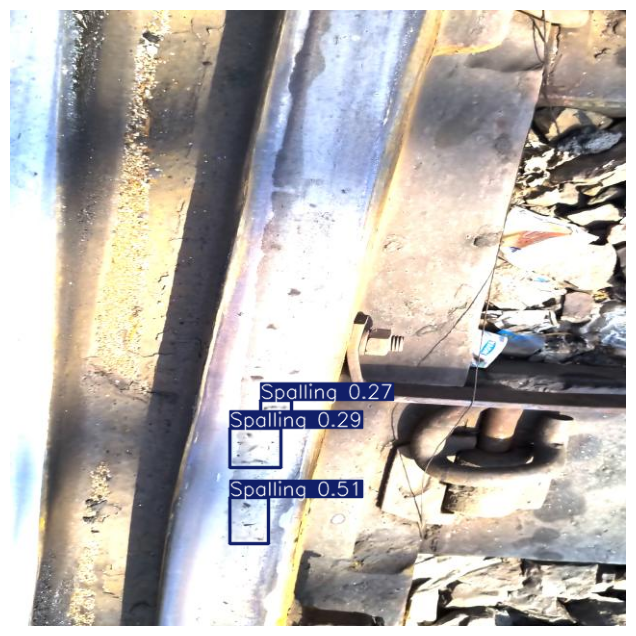

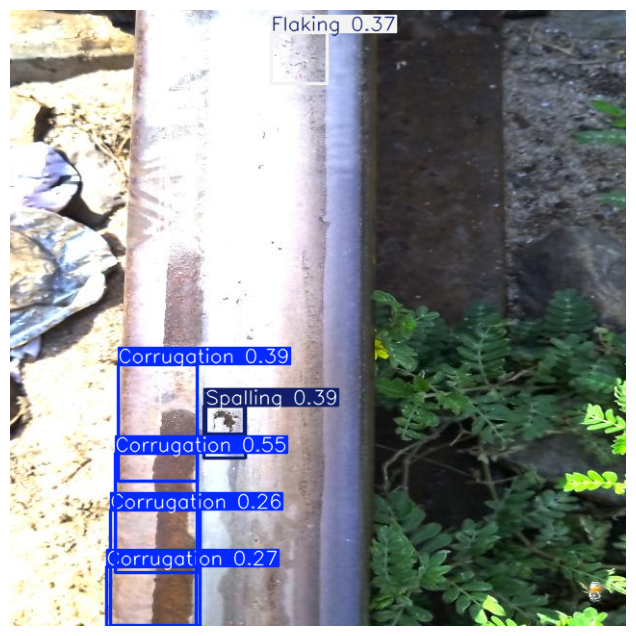

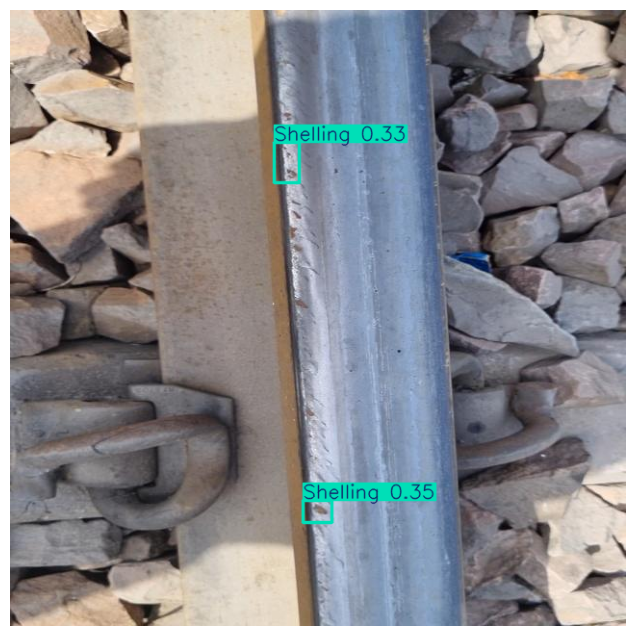

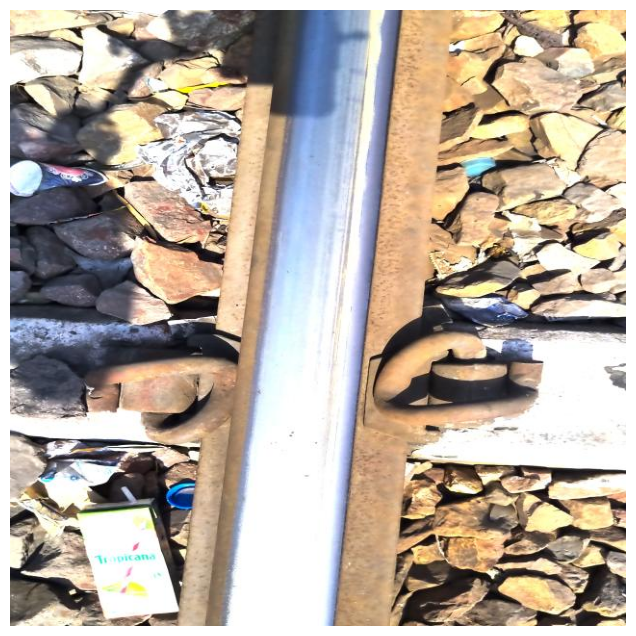

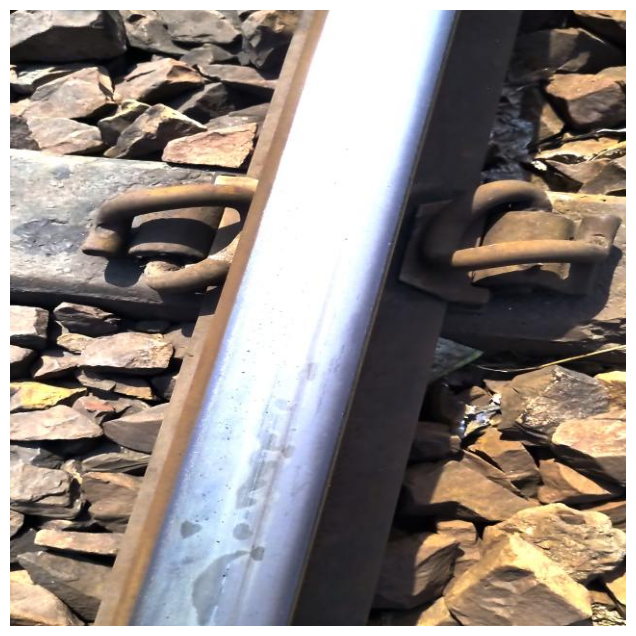

In [20]:
for result in results:
    predicted_images=result.plot()
    plt.figure(figsize=(10,8))
    plt.imshow(predicted_images[..., ::-1])
    plt.axis("off")
    plt.show()

In [22]:
import pandas as pd

df = pd.read_csv("../outputs/yolo/Rail_Defect_Detect_7class-2/results.csv")

print("Epochs completed:", len(df))
print(df.tail())

Epochs completed: 42
    epoch     time  train/box_loss  train/cls_loss  train/dfl_loss  \
37     38  3085.40         1.91163         1.61441         1.52663   
38     39  3164.47         1.91127         1.59262         1.51804   
39     40  3243.59         1.89638         1.56333         1.50302   
40     41  3322.49         1.88897         1.56520         1.49954   
41     42  3401.44         1.87084         1.53417         1.49466   

    metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
37               0.40617            0.38999           0.32793   
38               0.42134            0.38510           0.33380   
39               0.38961            0.40580           0.33507   
40               0.40655            0.40899           0.34183   
41               0.39014            0.41311           0.33748   

    metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
37              0.11641       2.25799       1.99520       1.77898  0.000576   
38       